# Exploratory Data Analysis (EDA) - Phishing Intelligence

This notebook serves as the **Research & Experimentation Phase** for the Tabular Structural Features engine. We will explore the UCI Phishing Websites Dataset to understand class distributions, feature correlations, and data anomalies before transitioning to the automated Python training scripts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings
warnings.filterwarnings('ignore')

# Set visual styles for enterprise reporting
plt.style.use('ggplot')
sns.set_palette('muted')

### 1. Data Ingestion & Cleaning
The original dataset is provided in `.arff` format. Weka environments encode categorical labels as byte-strings. We need to decode these and map the target variable to a standard Binary Cross-Entropy format (`1` for Phishing, `0` for Legitimate).

In [2]:
data_path = '../data/uci_phishing/dataset.arff'
data, meta = arff.loadarff(data_path)
df = pd.DataFrame(data)

# Decode byte strings to integers
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8').astype(int)

# Map Target: Original -1 (Phishing), 1 (Legitimate) -> New 1 (Phishing), 0 (Legitimate)
df['Result'] = df['Result'].map({-1: 1, 1: 0})

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,0


### 2. Target Variable Distribution
We must check for severe class imbalances. If one class vastly outweighs the other, our models (like XGBoost or the PyTorch ANN) will develop a bias and overfit the majority class, requiring SMOTE or class-weighting.

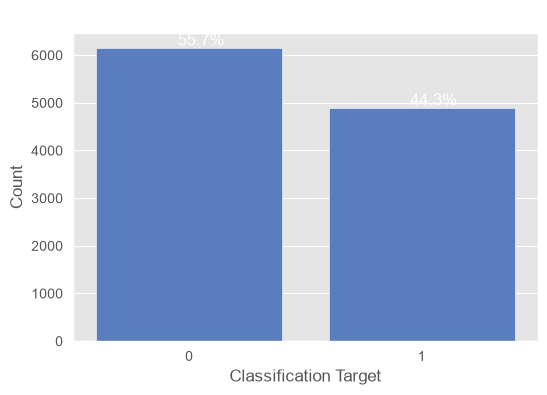

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Result')
plt.title('Target Distribution (0 = Legitimate, 1 = Phishing)')
plt.xlabel('Classification Target')
plt.ylabel('Count')

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), size=12)

plt.show()

# Conclusion: The dataset is relatively well-balanced (~55% vs ~44%). No SMOTE required.

### 3. Structural Correlation Heatmap
By visualizing the Pearson correlation coefficient, we can identify which structural parameters (e.g., SSL State, URL Anchors) are the strongest predictors of a phishing vector.

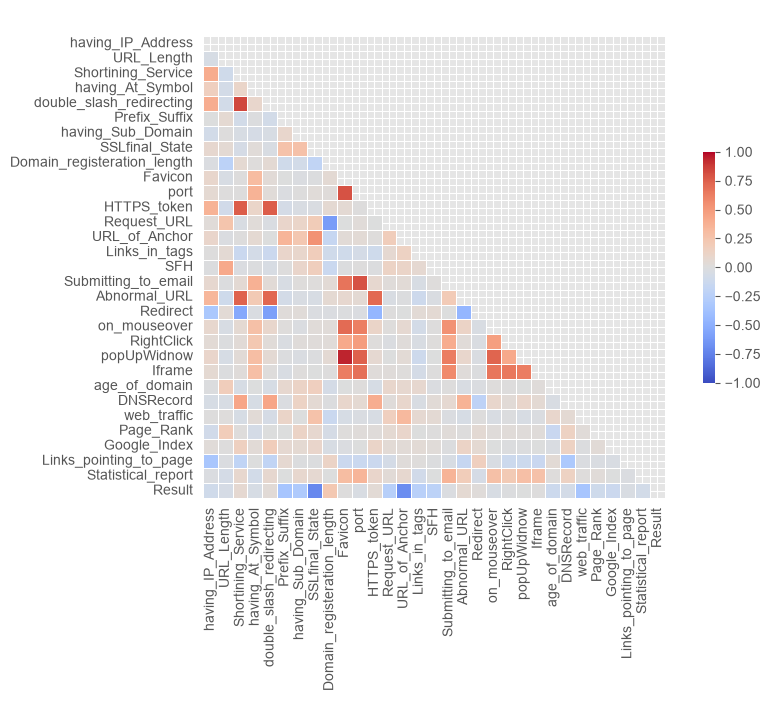

In [7]:
plt.figure(figsize=(10, 6))
corr = df.corr()

# Generate a mask for the upper triangle to make it cleaner
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Feature Correlation Heatmap', fontsize=18)
plt.show()

### 4. Isolating High-Impact Indicators
Based on the heatmap, `SSLfinal_State` and `URL_of_Anchor` exhibit strong positive/negative correlations with the threat label. Let's isolate their distributions.

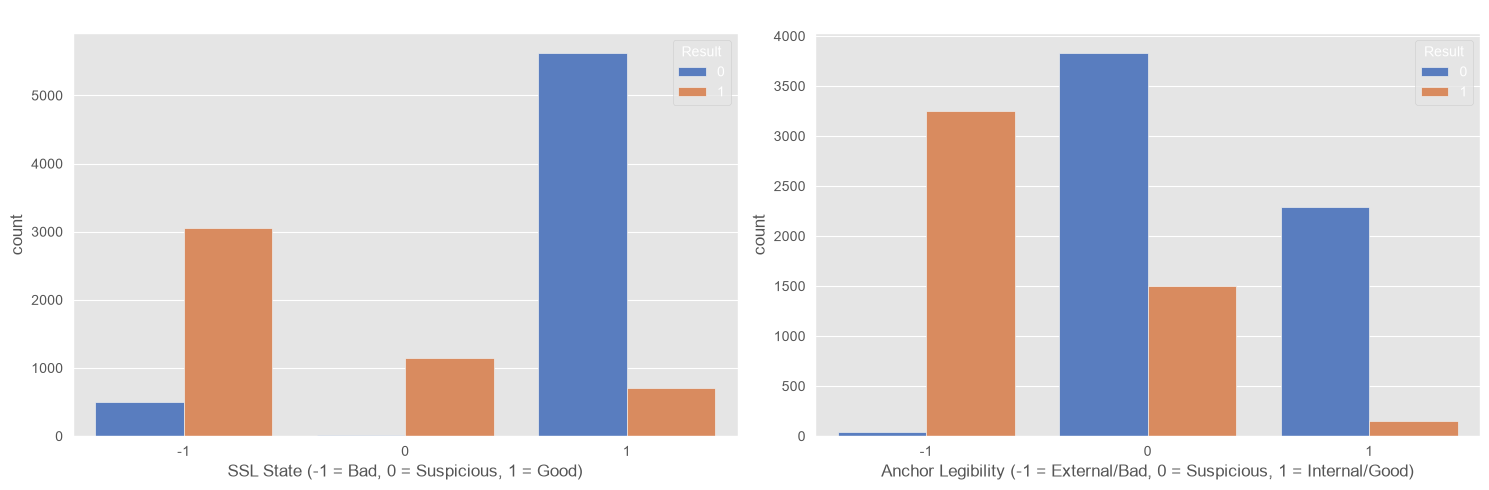

Observation: Websites with a bad SSL state (-1) are almost exclusively flagged as Phishing (1).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='SSLfinal_State', hue='Result', ax=axes[0])
axes[0].set_title('SSL Final State vs Phishing Risk')
axes[0].set_xlabel('SSL State (-1 = Bad, 0 = Suspicious, 1 = Good)')

sns.countplot(data=df, x='URL_of_Anchor', hue='Result', ax=axes[1])
axes[1].set_title('URL of Anchor vs Phishing Risk')
axes[1].set_xlabel('Anchor Legibility (-1 = External/Bad, 0 = Suspicious, 1 = Internal/Good)')

plt.tight_layout()
plt.show()

print("Observation: Websites with a bad SSL state (-1) are almost exclusively flagged as Phishing (1).")